Missing folder, skipping: recent_analysis_prof_unet/physics_tests
Missing folder, skipping: recent_analysis_split_na/physics_tests
Missing folder, skipping: recent_analysis_unet_na/physics_tests
Missing folder, skipping: baseline_full/final
Saved index: history_index.csv
See what was found.
                                                 name     model_type  \
0          border_physics_limited_attn_unet_darcy_0p0      attn_unet   
1        border_physics_limited_attn_unet_darcy_0p001      attn_unet   
2         border_physics_limited_attn_unet_darcy_0p01      attn_unet   
3          border_physics_limited_attn_unet_darcy_0p1      attn_unet   
4          border_physics_limited_attn_unet_darcy_1p0      attn_unet   
5         border_physics_limited_attn_unet_darcy_10p0      attn_unet   
6        border_physics_limited_attn_unet_darcy_100p0      attn_unet   
7       border_physics_limited_attn_unet_darcy_1000p0      attn_unet   
8      border_physics_limited_attn_unet_darcy_10000p0      a

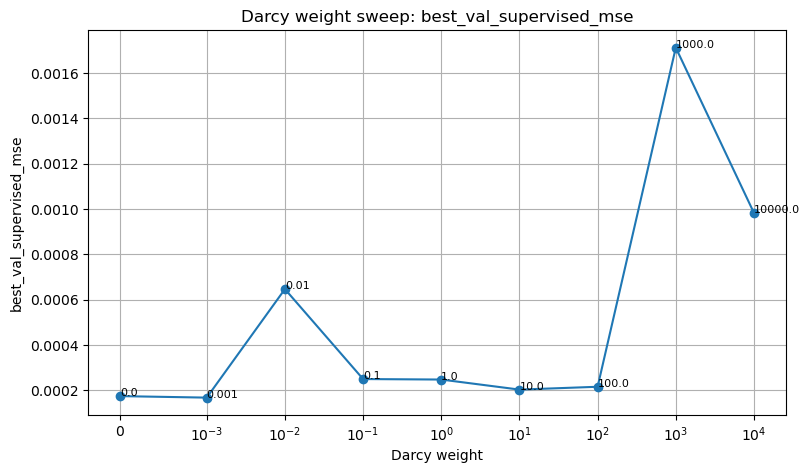

Example 2: Compare architectures at the same dataset and Darcy weight.


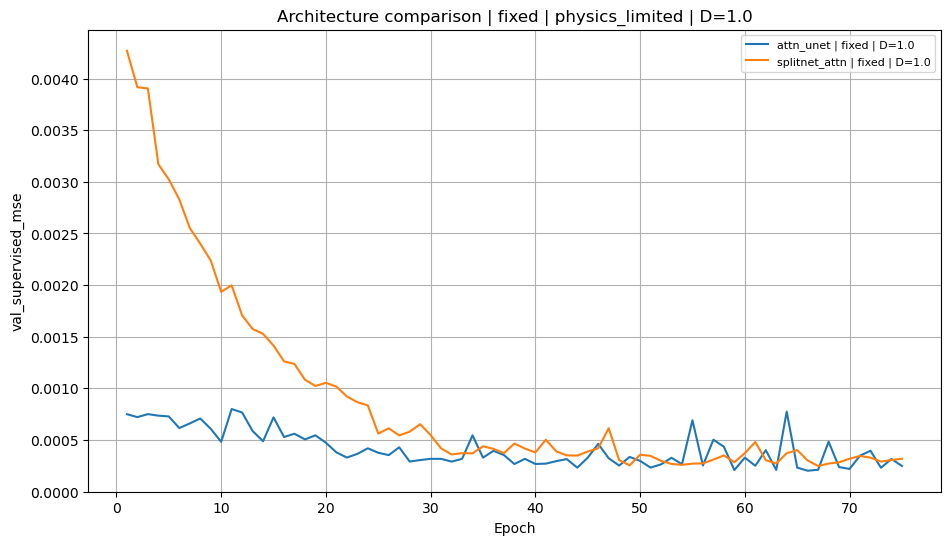

Example 3: Compare attention vs no attention for SplitNet.


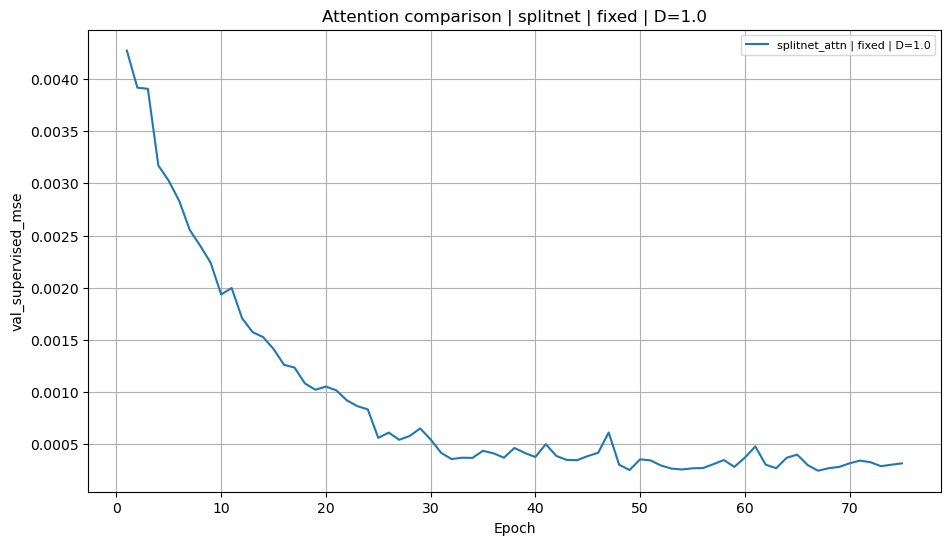

Example 4: Compare mask/nonmask behavior for selected models.


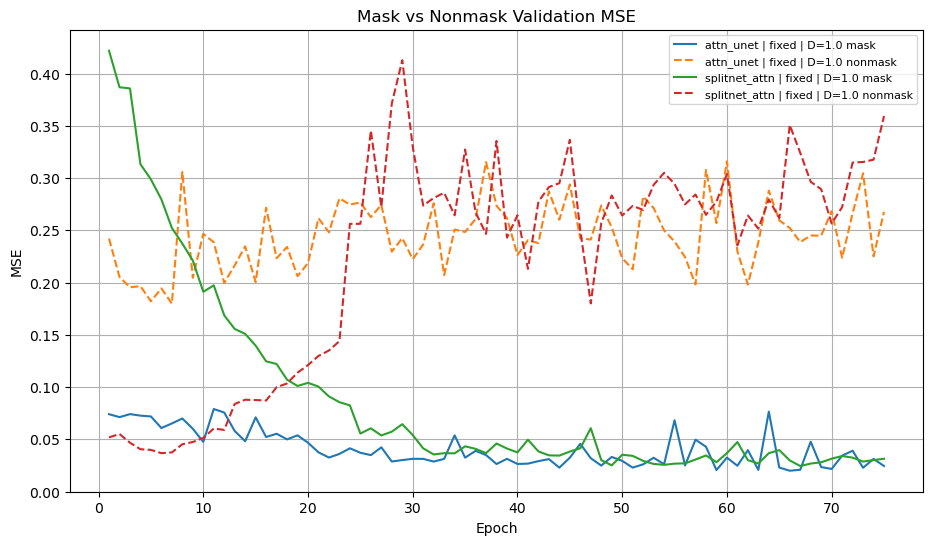

Example 5: Compare physics run against its full-supervision baseline.


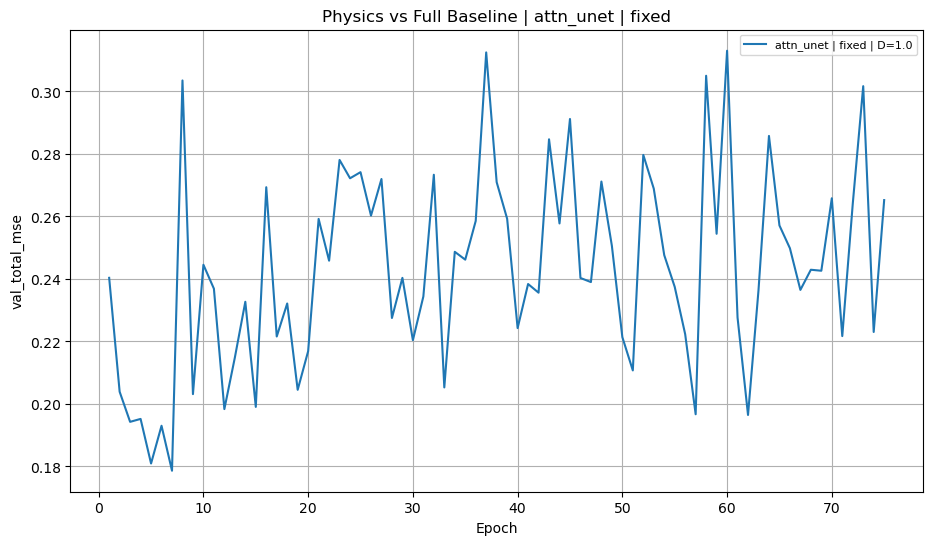

In [5]:
import re
from pathlib import Path
from typing import Optional, Sequence, Dict, Any

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# 1. Tell the script where each family of experiments lives
# -----------------------------------------------------------------------------

EXPERIMENT_ROOTS = {
    # physics-limited sweeps
    "splitnet_attn": "recent_analysis/physics_tests",
    "attn_unet": "recent_analysis_unet/physics_tests",
    "prof_unet": "recent_analysis_prof_unet/physics_tests",
    "splitnet": "recent_analysis_split_na/physics_tests",
    "unet": "recent_analysis_unet_na/physics_tests",

    # full-supervision baselines
    "baseline_full": "baseline_full/final",
}

DATASET_MODES = ["border_pressure", "border", "fixed"]
MODEL_TYPES = ["splitnet_attn", "splitnet", "unet", "attn_unet", "prof_unet"]


# -----------------------------------------------------------------------------
# 2. Filename parsing
# -----------------------------------------------------------------------------


def _safe_weight_to_float(weight_text: str) -> Optional[float]:
    """
    Converts strings like '0p001', '1p0', '1000p0' into floats.
    Returns None if no real Darcy weight exists, as in baseline_full files.
    """
    if weight_text is None:
        return None
    try:
        return float(weight_text.replace("p", "."))
    except Exception:
        return None


def get_history_name(path: str | Path) -> str:
    """Filename without '_history.csv'."""
    stem = Path(path).stem
    return stem.replace("_history", "")


def infer_dataset_mode(name: str) -> Optional[str]:
    # Order matters: border_pressure contains border.
    for mode in DATASET_MODES:
        if name.startswith(mode + "_") or f"_{mode}_" in name:
            return mode
    return None


def infer_model_type(name: str, root_key: Optional[str] = None) -> Optional[str]:
    """
    Prefer root key when scanning physics folders because filenames can be messy.
    Fall back to filename matching.
    """
    if root_key in MODEL_TYPES:
        return root_key

    # Order matters: splitnet_attn contains splitnet, attn_unet contains unet.
    for model_type in ["splitnet_attn", "attn_unet", "prof_unet", "splitnet", "unet"]:
        if model_type in name:
            return model_type
    return None


def infer_training_mode(name: str, root_key: Optional[str] = None) -> str:
    if root_key == "baseline_full" or "baseline_full" in name:
        return "baseline_full"
    if "physics_limited" in name:
        return "physics_limited"
    return "unknown"


def infer_darcy_weight(name: str, training_mode: str) -> Optional[float]:
    if training_mode == "baseline_full":
        return 0.0

    match = re.search(r"darcy_([0-9]+p[0-9]+|[0-9]+)", name)
    if not match:
        return None
    return _safe_weight_to_float(match.group(1))


def infer_attention(model_type: Optional[str]) -> Optional[bool]:
    if model_type is None:
        return None
    if model_type in ["splitnet_attn", "attn_unet"]:
        return True
    if model_type in ["splitnet", "unet", "prof_unet"]:
        return False
    return None


def infer_arch_family(model_type: Optional[str]) -> Optional[str]:
    if model_type is None:
        return None
    if model_type in ["splitnet_attn", "splitnet"]:
        return "splitnet"
    if model_type in ["attn_unet", "unet"]:
        return "small_unet"
    if model_type == "prof_unet":
        return "prof_unet"
    return None


# -----------------------------------------------------------------------------
# 3. Build an index/table of every history CSV
# -----------------------------------------------------------------------------


def summarize_history_csv(path: str | Path) -> Dict[str, Any]:
    """
    Reads one *_history.csv and returns useful summary values.
    This lets you sort/filter without opening every file manually later.
    """
    df = pd.read_csv(path)

    summary = {
        "epochs": int(df["epoch"].max()) if "epoch" in df.columns else len(df),
    }

    metrics = [
        "train_loss_used",
        "train_total_mse",
        "train_supervised_mse",
        "train_mask_mse",
        "train_nonmask_mse",
        "train_darcy",
        "val_total_mse",
        "val_supervised_mse",
        "val_mask_mse",
        "val_nonmask_mse",
        "val_darcy",
    ]

    for metric in metrics:
        if metric in df.columns:
            summary[f"best_{metric}"] = df[metric].min()
            summary[f"final_{metric}"] = df[metric].iloc[-1]
            summary[f"best_epoch_{metric}"] = int(df.loc[df[metric].idxmin(), "epoch"])

    return summary


def build_history_index(
    experiment_roots: Dict[str, str] = EXPERIMENT_ROOTS,
    save_csv: Optional[str] = "history_index.csv",
) -> pd.DataFrame:
    """
    Scans every configured folder and builds one row per *_history.csv file.

    The returned DataFrame is the central object for filtering/plotting.
    """
    rows = []

    for root_key, root in experiment_roots.items():
        root_path = Path(root)
        if not root_path.exists():
            print(f"Missing folder, skipping: {root}")
            continue

        for path in sorted(root_path.rglob("*_history.csv")):
            name = get_history_name(path)
            training_mode = infer_training_mode(name, root_key=root_key)
            model_type = infer_model_type(name, root_key=root_key)
            dataset_mode = infer_dataset_mode(name)
            darcy_weight = infer_darcy_weight(name, training_mode)

            row = {
                "name": name,
                "path": str(path),
                "root_key": root_key,
                "model_type": model_type,
                "arch_family": infer_arch_family(model_type),
                "has_attention": infer_attention(model_type),
                "dataset_mode": dataset_mode,
                "training_mode": training_mode,
                "darcy_weight": darcy_weight,
            }

            try:
                row.update(summarize_history_csv(path))
            except Exception as e:
                row["error"] = str(e)

            rows.append(row)

    index = pd.DataFrame(rows)

    if len(index) > 0:
        sort_cols = ["dataset_mode", "model_type", "training_mode", "darcy_weight"]
        sort_cols = [c for c in sort_cols if c in index.columns]
        index = index.sort_values(sort_cols, na_position="last").reset_index(drop=True)

    if save_csv is not None:
        index.to_csv(save_csv, index=False)
        print(f"Saved index: {save_csv}")

    return index


# -----------------------------------------------------------------------------
# 4. Filtering helpers
# -----------------------------------------------------------------------------


def filter_histories(
    index: pd.DataFrame,
    model_type: Optional[str | Sequence[str]] = None,
    arch_family: Optional[str | Sequence[str]] = None,
    dataset_mode: Optional[str | Sequence[str]] = None,
    training_mode: Optional[str | Sequence[str]] = None,
    darcy_weight: Optional[float | Sequence[float]] = None,
    has_attention: Optional[bool] = None,
    name_contains: Optional[str] = None,
) -> pd.DataFrame:
    """Flexible filter over the history index."""
    df = index.copy()

    def apply_filter(df, col, value):
        if value is None:
            return df
        if isinstance(value, (list, tuple, set)):
            return df[df[col].isin(value)]
        return df[df[col] == value]

    df = apply_filter(df, "model_type", model_type)
    df = apply_filter(df, "arch_family", arch_family)
    df = apply_filter(df, "dataset_mode", dataset_mode)
    df = apply_filter(df, "training_mode", training_mode)
    df = apply_filter(df, "has_attention", has_attention)

    if darcy_weight is not None:
        if isinstance(darcy_weight, (list, tuple, set)):
            df = df[df["darcy_weight"].isin(darcy_weight)]
        else:
            df = df[df["darcy_weight"] == darcy_weight]

    if name_contains is not None:
        df = df[df["name"].str.contains(name_contains, na=False)]

    return df.reset_index(drop=True)


def show_top(
    index: pd.DataFrame,
    metric: str = "best_val_supervised_mse",
    n: int = 20,
    dataset_mode: Optional[str] = None,
    training_mode: Optional[str] = None,
):
    """Quick text/table view of the best runs by a metric."""
    df = index.copy()
    if dataset_mode is not None:
        df = df[df["dataset_mode"] == dataset_mode]
    if training_mode is not None:
        df = df[df["training_mode"] == training_mode]

    cols = [
        "name", "model_type", "dataset_mode", "training_mode", "darcy_weight",
        metric, "best_val_total_mse", "best_val_nonmask_mse", "best_val_darcy", "path"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(metric).head(n)[cols]


# -----------------------------------------------------------------------------
# 5. Plotting helpers
# -----------------------------------------------------------------------------


def _label_from_row(row, label_style="compact") -> str:
    if label_style == "name":
        return row["name"]

    pieces = [str(row.get("model_type")), str(row.get("dataset_mode"))]

    if row.get("training_mode") == "baseline_full":
        pieces.append("baseline")
    else:
        pieces.append(f"D={row.get('darcy_weight')}")

    return " | ".join(pieces)


def plot_metric_curves(
    runs: pd.DataFrame,
    metric: str = "val_supervised_mse",
    title: Optional[str] = None,
    label_style: str = "compact",
    log_y: bool = False,
    max_runs: int = 12,
):
    """
    Plots one metric over epochs for all rows in runs.

    Good metrics:
        val_supervised_mse
        val_total_mse
        val_mask_mse
        val_nonmask_mse
        val_darcy
        train_loss_used
    """
    if len(runs) == 0:
        print("No runs to plot.")
        return

    if len(runs) > max_runs:
        print(f"Warning: plotting first {max_runs} of {len(runs)} runs. Filter more tightly if needed.")
        runs = runs.head(max_runs)

    plt.figure(figsize=(11, 6))

    for _, row in runs.iterrows():
        df = pd.read_csv(row["path"])
        if metric not in df.columns:
            print(f"Skipping {row['name']}: missing metric {metric}")
            continue
        plt.plot(df["epoch"], df[metric], label=_label_from_row(row, label_style=label_style))

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title or metric)
    if log_y:
        plt.yscale("log")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()


def plot_train_val_pair(
    runs: pd.DataFrame,
    base_metric: str = "supervised_mse",
    title: Optional[str] = None,
    label_style: str = "compact",
    log_y: bool = False,
    max_runs: int = 6,
):
    """
    Plots train and val versions of a metric for several runs.

    base_metric examples:
        supervised_mse -> train_supervised_mse / val_supervised_mse
        total_mse      -> train_total_mse / val_total_mse
        darcy          -> train_darcy / val_darcy
    """
    train_col = f"train_{base_metric}"
    val_col = f"val_{base_metric}"

    if len(runs) > max_runs:
        print(f"Warning: plotting first {max_runs} of {len(runs)} runs. Filter more tightly if needed.")
        runs = runs.head(max_runs)

    plt.figure(figsize=(11, 6))

    for _, row in runs.iterrows():
        df = pd.read_csv(row["path"])
        label = _label_from_row(row, label_style=label_style)

        if train_col in df.columns:
            plt.plot(df["epoch"], df[train_col], linestyle="-", label=f"{label} train")
        if val_col in df.columns:
            plt.plot(df["epoch"], df[val_col], linestyle="--", label=f"{label} val")

    plt.xlabel("Epoch")
    plt.ylabel(base_metric)
    plt.title(title or f"Train vs Val {base_metric}")
    if log_y:
        plt.yscale("log")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()


def plot_mask_vs_nonmask(
    runs: pd.DataFrame,
    title: Optional[str] = None,
    label_style: str = "compact",
    log_y: bool = False,
    max_runs: int = 6,
):
    """Plots val_mask_mse and val_nonmask_mse for selected runs."""
    if len(runs) > max_runs:
        print(f"Warning: plotting first {max_runs} of {len(runs)} runs. Filter more tightly if needed.")
        runs = runs.head(max_runs)

    plt.figure(figsize=(11, 6))

    for _, row in runs.iterrows():
        df = pd.read_csv(row["path"])
        label = _label_from_row(row, label_style=label_style)

        if "val_mask_mse" in df.columns:
            plt.plot(df["epoch"], df["val_mask_mse"], linestyle="-", label=f"{label} mask")
        if "val_nonmask_mse" in df.columns:
            plt.plot(df["epoch"], df["val_nonmask_mse"], linestyle="--", label=f"{label} nonmask")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(title or "Mask vs Nonmask Validation MSE")
    if log_y:
        plt.yscale("log")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()


def plot_darcy_weight_curve(
    runs: pd.DataFrame,
    y_metric: str = "best_val_supervised_mse",
    title: Optional[str] = None,
    log_x: bool = True,
    log_y: bool = False,
):
    """
    Plots a sweep curve: Darcy weight vs summary metric.
    Best used after filtering to one model_type and one dataset_mode.
    """
    df = runs.copy()
    df = df[df["training_mode"] == "physics_limited"]
    df = df[df["darcy_weight"].notna()]
    df = df.sort_values("darcy_weight")

    if len(df) == 0:
        print("No physics_limited Darcy sweep runs found.")
        return

    plt.figure(figsize=(9, 5))
    plt.plot(df["darcy_weight"], df[y_metric], marker="o")

    for _, row in df.iterrows():
        plt.annotate(str(row["darcy_weight"]), (row["darcy_weight"], row[y_metric]), fontsize=8)

    plt.xlabel("Darcy weight")
    plt.ylabel(y_metric)
    plt.title(title or f"Darcy weight sweep: {y_metric}")
    if log_x:
        plt.xscale("symlog", linthresh=0.001)
    if log_y:
        plt.yscale("log")
    plt.grid(True)
    plt.show()


# -----------------------------------------------------------------------------
# 6. Higher-level comparison shortcuts
# -----------------------------------------------------------------------------


def compare_architectures(
    index: pd.DataFrame,
    dataset_mode: str,
    darcy_weight: Optional[float] = None,
    training_mode: str = "physics_limited",
    metric: str = "val_supervised_mse",
):
    runs = filter_histories(
        index,
        dataset_mode=dataset_mode,
        training_mode=training_mode,
        darcy_weight=darcy_weight,
    )
    plot_metric_curves(
        runs,
        metric=metric,
        title=f"Architecture comparison | {dataset_mode} | {training_mode} | D={darcy_weight}",
    )


def compare_attention_effect(
    index: pd.DataFrame,
    dataset_mode: str,
    arch_family: str,
    darcy_weight: Optional[float],
    metric: str = "val_supervised_mse",
):
    runs = filter_histories(
        index,
        dataset_mode=dataset_mode,
        arch_family=arch_family,
        training_mode="physics_limited",
        darcy_weight=darcy_weight,
    )
    plot_metric_curves(
        runs,
        metric=metric,
        title=f"Attention comparison | {arch_family} | {dataset_mode} | D={darcy_weight}",
    )


def compare_dataset_modes(
    index: pd.DataFrame,
    model_type: str,
    darcy_weight: Optional[float],
    metric: str = "val_supervised_mse",
):
    runs = filter_histories(
        index,
        model_type=model_type,
        training_mode="physics_limited",
        darcy_weight=darcy_weight,
    )
    plot_metric_curves(
        runs,
        metric=metric,
        title=f"Dataset comparison | {model_type} | D={darcy_weight}",
    )


def compare_physics_vs_baseline(
    index: pd.DataFrame,
    model_type: str,
    dataset_mode: str,
    physics_darcy_weight: float,
    metric: str = "val_total_mse",
):
    """
    Compares one selected physics run to the matching full baseline.

    For physics_limited, val_supervised_mse tracks sparse-region loss.
    For baseline_full, val_total_mse tracks full-image loss.
    Use metric='val_total_mse' or 'val_nonmask_mse' when comparing global behavior.
    """
    physics = filter_histories(
        index,
        model_type=model_type,
        dataset_mode=dataset_mode,
        training_mode="physics_limited",
        darcy_weight=physics_darcy_weight,
    )
    baseline = filter_histories(
        index,
        model_type=model_type,
        dataset_mode=dataset_mode,
        training_mode="baseline_full",
    )

    runs = pd.concat([physics, baseline], ignore_index=True)
    plot_metric_curves(
        runs,
        metric=metric,
        title=f"Physics vs Full Baseline | {model_type} | {dataset_mode}",
    )


# -----------------------------------------------------------------------------
# 7. Example usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # Build the table of every history file.
    index = build_history_index(save_csv="history_index.csv")

    # See what was found.
    print("See what was found.")
    print(index[["name", "model_type", "dataset_mode", "training_mode", "darcy_weight", "path"]].head(20))

    # Find strongest runs by validation supervised MSE.
    print("Find strongest runs by validation supervised MSE.")
    print(show_top(index, metric="best_val_supervised_mse", n=15))

    # Example 1: Darcy weight curve for one model/dataset.
    print("Example 1: Darcy weight curve for one model/dataset.")
    runs = filter_histories(index, model_type="splitnet_attn", dataset_mode="fixed")
    plot_darcy_weight_curve(runs, y_metric="best_val_supervised_mse")

    # Example 2: Compare architectures at the same dataset and Darcy weight.
    print("Example 2: Compare architectures at the same dataset and Darcy weight.")
    compare_architectures(index, dataset_mode="fixed", darcy_weight=1.0, metric="val_supervised_mse")

    # Example 3: Compare attention vs no attention for SplitNet.
    print("Example 3: Compare attention vs no attention for SplitNet.")
    compare_attention_effect(index, dataset_mode="fixed", arch_family="splitnet", darcy_weight=1.0)

    # Example 4: Compare mask/nonmask behavior for selected models.
    print("Example 4: Compare mask/nonmask behavior for selected models.")
    selected = filter_histories(
        index,
        model_type=["splitnet_attn", "attn_unet", "prof_unet"],
        dataset_mode="fixed",
        training_mode="physics_limited",
        darcy_weight=1.0,
    )
    plot_mask_vs_nonmask(selected, log_y=False)

    # Example 5: Compare physics run against its full-supervision baseline.
    print("Example 5: Compare physics run against its full-supervision baseline.")
    compare_physics_vs_baseline(
        index,
        model_type="attn_unet",
        dataset_mode="fixed",
        physics_darcy_weight=1.0,
        metric="val_total_mse",
    )


In [4]:
index = build_history_index()
show_top(index, metric="best_val_supervised_mse", n=20)

Missing folder, skipping: recent_analysis_prof_unet/physics_tests
Missing folder, skipping: recent_analysis_split_na/physics_tests
Missing folder, skipping: recent_analysis_unet_na/physics_tests
Missing folder, skipping: baseline_full/final
Saved index: history_index.csv


,name,model_type,dataset_mode,training_mode,darcy_weight,best_val_supervised_mse,best_val_total_mse,best_val_nonmask_mse,best_val_darcy,path
44,fixed_physics_limited_splitnet_attn_darcy_0p001,splitnet_attn,fixed,physics_limited,0.001,0.000167,0.037146,0.033632,2.004176e-06,recent_analysis/physics_tests/fixed/fixed_phys...
43,fixed_physics_limited_splitnet_attn_darcy_0p0,splitnet_attn,fixed,physics_limited,0.000,0.000174,0.088285,0.087230,6.775901e-05,recent_analysis/physics_tests/fixed/fixed_phys...
35,fixed_physics_limited_attn_unet_darcy_0p001,attn_unet,fixed,physics_limited,0.001,0.000177,0.099180,0.097962,4.614680e-05,recent_analysis_unet/physics_tests/fixed/fixed...
40,fixed_physics_limited_attn_unet_darcy_100p0,attn_unet,fixed,physics_limited,100.000,0.000178,0.015516,0.011525,8.595241e-08,recent_analysis_unet/physics_tests/fixed/fixed...
37,fixed_physics_limited_attn_unet_darcy_0p1,attn_unet,fixed,physics_limited,0.100,0.000182,0.040916,0.038583,1.015851e-05,recent_analysis_unet/physics_tests/fixed/fixed...
34,fixed_physics_limited_attn_unet_darcy_0p0,attn_unet,fixed,physics_limited,0.000,0.000193,0.066459,0.062735,1.490753e-05,recent_analysis_unet/physics_tests/fixed/fixed...
38,fixed_physics_limited_attn_unet_darcy_1p0,attn_unet,fixed,physics_limited,1.000,0.000202,0.178633,0.179793,1.321066e-06,recent_analysis_unet/physics_tests/fixed/fixed...
48,fixed_physics_limited_splitnet_attn_darcy_10p0,splitnet_attn,fixed,physics_limited,10.000,0.000203,0.008778,0.005739,1.324626e-07,recent_analysis/physics_tests/fixed/fixed_phys...
49,fixed_physics_limited_splitnet_attn_darcy_100p0,splitnet_attn,fixed,physics_limited,100.000,0.000215,0.024599,0.022446,8.772118e-08,recent_analysis/physics_tests/fixed/fixed_phys...
47,fixed_physics_limited_splitnet_attn_darcy_1p0,splitnet_attn,fixed,physics_limited,1.000,0.000247,0.039163,0.036704,3.865198e-07,recent_analysis/physics_tests/fixed/fixed_phys...
